# 04 -- Modeling Results

Loads the real, already-trained models from `src/modeling.py` (`python src/modeling.py`) and the metrics it wrote to `reports/model_metrics.json`. No numbers here are recomputed or re-tuned for presentation -- this notebook just visualizes what `modeling.py` already produced.

In [1]:
import sys
sys.path.insert(0, "../src")
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
con = duckdb.connect("../data/cms_medicare.duckdb", read_only=True)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

import json
import joblib
import numpy as np
from sklearn.metrics import confusion_matrix, RocCurveDisplay, roc_curve
from features import build_model1_frame, build_model2_frame,\
    MODEL1_NUMERIC_FEATURES, MODEL1_CATEGORICAL_FEATURES,\
    MODEL2_NUMERIC_FEATURES, MODEL2_CATEGORICAL_FEATURES

metrics = json.load(open("../reports/model_metrics.json"))

## Model 1 -- Medicare Spending Prediction

In [2]:
m1 = metrics["model1_payment_regression"]
print(f"Train years: {m1['train_years']}  Test year: {m1['test_year']}")
print(f"n_train={m1['n_train']:,}  n_test={m1['n_test']:,}")
print(f"MAE  = ${m1['mae']:,.2f}")
print(f"RMSE = ${m1['rmse']:,.2f}")
print(f"R2   = {m1['r2']:.4f}")

Train years: [2018, 2019, 2020, 2021, 2022]  Test year: 2023
n_train=5,512,349  n_test=1,175,272
MAE  = $25,712.03
RMSE = $617,042.83
R2   = 0.2804


## Model 2 -- Specialty-Adjusted High-Cost Classification

In [3]:
m2 = metrics["model2_high_cost_classification"]
print(f"Label: {m2['label_definition']}")
print(f"Train years: {m2['train_years']}  Test year: {m2['test_year']}")
print(f"Positive rate (test): {m2['positive_rate_test']:.1%}")
for k in ['precision','recall','f1','roc_auc','pr_auc']:
    print(f"{k:>10}: {m2[k]:.3f}")

Label: payment_per_beneficiary at or above the 90th percentile of the provider's own specialty-year peer group (peer_group_size >= 30)
Train years: [2018, 2019, 2020, 2021, 2022]  Test year: 2023
Positive rate (test): 10.0%
 precision: 0.353
    recall: 0.853
        f1: 0.499
   roc_auc: 0.925
    pr_auc: 0.677


## Model 2 confusion matrix

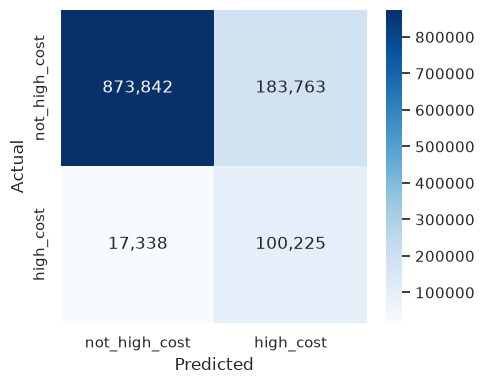

In [4]:
cm = np.array(m2["confusion_matrix"]["matrix"])
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt=",", cmap="Blues",
            xticklabels=m2["confusion_matrix"]["labels"],
            yticklabels=m2["confusion_matrix"]["labels"], ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout(); plt.show()

## Model 2 ROC curve (recomputed on the same test-year holdout)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

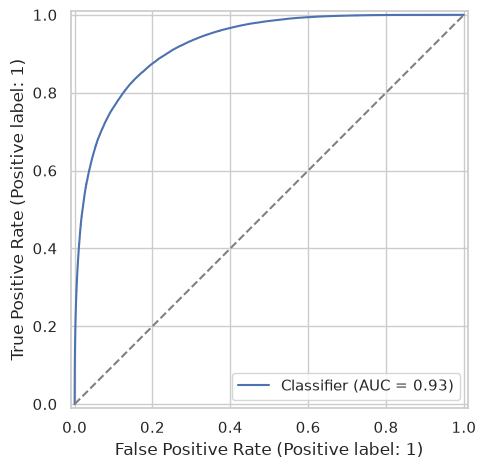

In [5]:
model2 = joblib.load("../models/model2_high_cost_classifier.joblib")
df2 = build_model2_frame(con)
for c in MODEL2_CATEGORICAL_FEATURES:
    df2[c] = df2[c].astype("category")
test = df2[df2["source_year"] == m2["test_year"]]
X_test = test[MODEL2_NUMERIC_FEATURES + MODEL2_CATEGORICAL_FEATURES]
y_test = test["is_high_cost_p90"]
proba = model2.predict_proba(X_test)[:, 1]
fig, ax = plt.subplots(figsize=(5,5))
RocCurveDisplay.from_predictions(y_test, proba, ax=ax)
ax.plot([0,1],[0,1], linestyle="--", color="gray")
plt.tight_layout(); plt.show()

## Feature importance (both models)

Saved by `src/modeling.py` to `reports/figures/`; displayed here for convenience.

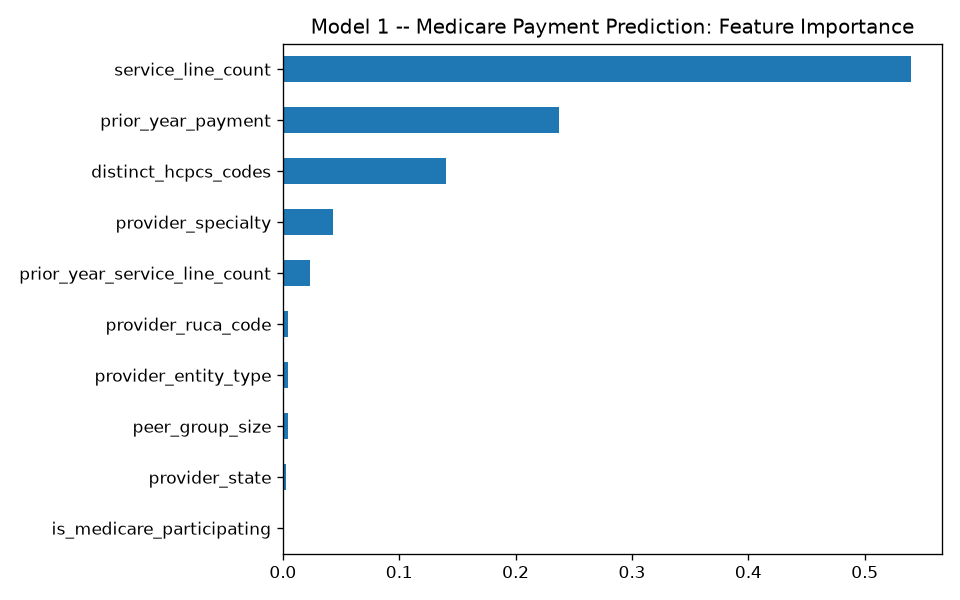

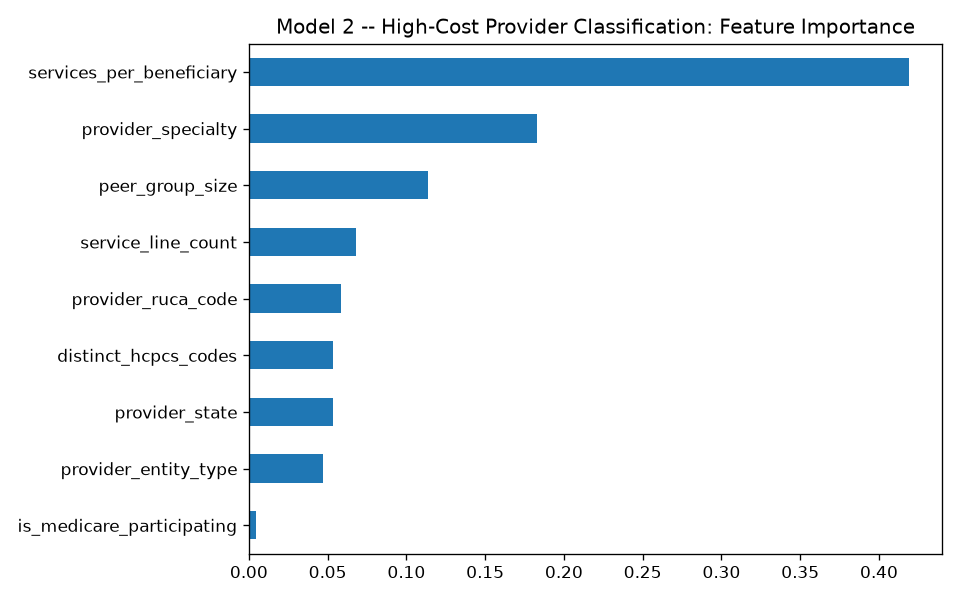

In [6]:
from IPython.display import Image, display
display(Image("../reports/figures/model1_feature_importance.png"))
display(Image("../reports/figures/model2_feature_importance.png"))